# Расчет ключевых метрик сервиса Яндекс Книги и проверка гипотезы

# Часть 1. Расчёт метрик в PostgreSQL

В нашем распоряжении имеется несколько таблиц, содержащих данные о чтении и прослушивании контента в сервисе Яндекс Книги, которые включают информацию о пользователях, платформах, времени, длительности сессий и типах контента. Данные представлены за период с 1 сентября по 11 декабря 2024 года.

## Описание данных

Таблица `bookmate.audition` содержит данные об активности пользователей и состоит из следующих полей:

-    `audition_id` — уникальный идентификатор сессии чтения или прослушивания;
-    `puid` — идентификатор пользователя;
-    `usage_platform_ru` — название платформы, с помощью которой пользователь слушал контент;
-    `msk_business_dt_str` — дата события в формате строки (московское время);
-    `app_version` — версия приложения, которая использовалась для чтения или прослушивания;
-    `adult_content_flg` — был ли это контент для взрослых: True или False;
-    `hours` — длительность чтения или прослушивания в часах;
-    `hours_sessions_long` — продолжительность длинных сессий чтения или прослушивания в часах;
-    `kids_content_flg` — был ли это детский контент: True или False;
-    `main_content_id` — идентификатор основного контента;
-    `usage_geo_id` — идентификатор географического местоположения.

Таблица `bookmate.content` содержит данные о контенте и состоит из следующих полей:

-    `main_content_id` — идентификатор основного контента;
-    `main_author_id` — идентификатор основного автора контента;
-    `main_content_type` — тип контента;
-    `main_content_name` — название контента;
-    `main_content_duration_hours` — длительность контента в часах;
-    `published_topic_title_list` — список жанров контента.

Таблица `bookmate.author` содержит данные об авторах контента и состоит из следующих полей:

-    `main_author_id` — идентификатор основного автора контента;
-    `main_author_name` — имя основного автора контента.

Таблица `bookmate.geo` содержит данные о местоположении и состоит из следующих полей:

-    `usage_geo_id` — идентификатор географического положения;
-    `usage_geo_id_name` — город или регион географического положения;
-    `usage_country_name` — страна географического положения.

## Цель
Необходимо провести анализ и рассчитать ключевые метрики активности пользователей сервиса Яндекс Книги. Цель — глубже понять поведение пользователей и найти примечательные закономерности. Эти расчёты помогут понять, как пользователи взаимодействуют с платформой, какие виды контента наиболее популярны, а также выявить особенности поведения пользователей.

## 1. Расчёт MAU авторов
MAU будет определяться как количество уникальных пользователей в месяц, которые читали или слушали конкретного автора. Необходимо вывести имена топ-3 авторов с наибольшим MAU в ноябре и сами значения MAU.  
В результат должны войти следующие поля:
-    main_author_name — имя автора контента;
-    mau — значение MAU.  

Результат нужно отсортировать по значению MAU в порядке убывания.

In [ ]:
select main_author_name, count(distinct puid) as mau
from bookmate.audition as a
inner join bookmate.content as c on a.main_content_id = c.main_content_id
inner join bookmate.author as au on c.main_author_id = au.main_author_id
where extract(month from msk_business_dt_str::date) = 11
group by main_author_name
order by mau desc
limit 3

main_author_name |	mau
:------------- | -------------:
Андрей Усачев |	7107
Лиана Шнайдер |	3338
Игорь Носов |	3063

## 2. Расчёт MAU произведений
Необходимо выведсти имена топ-3 произведений с наибольшим MAU в ноябре, а также списки жанров этих произведений, их авторов и сами значения MAU.  
В результат должны войти следующие поля:
-    main_content_name — название произведения, или контента;
-    published_topic_title_list — список жанров контента;
-    main_author_name — имя автора контента;
-    mau — значение MAU.

Результат нужно отсортировать по значению MAU в порядке убывания.

In [ ]:
select main_content_name, published_topic_title_list, main_author_name, count(distinct puid) as mau
from bookmate.audition as a
inner join bookmate.content as c on a.main_content_id = c.main_content_id
inner join bookmate.author as au on c.main_author_id = au.main_author_id
where extract(month from msk_business_dt_str) = 11
group by main_content_name, published_topic_title_list, main_author_name
order by mau desc
limit 3

main_content_name |	published_topic_title_list |	main_author_name |	mau
:------------- | :------------- |:-------------: |-------------:
Собачка Соня на даче |	['Детская проза и поэзия', 'Аудио'] |	Андрей Усачев |	4597
Женькин клад и другие школьные рассказы |	['Сказки и фольклор', 'Детская проза и поэзия', 'Аудио'] |	Игорь Носов |	3050
Знаменитая собачка Соня |	['Аудиоспектакли', 'Детская проза и поэзия', 'Аудио'] |	Андрей Усачев |	2785


## 3. Расчёт Retention Rate
Команда сервиса провела рекламную кампанию, которая 2 декабря привлекла множество пользователей. Задача — проанализировать ежедневный Retention Rate всех пользователей, которые были активны 2 декабря. При этом неважно, новые это пользователи или нет.
Требуется рассчитать ежедневный Retention Rate пользователей до конца представленных данных. Неоьходимо вывести следующие поля:
-    `day_since_install` — срок жизни пользователя в днях;
-    `retained_users` — количество пользователей, которые вернулись в приложение в конкретный день;
-    `retention_rate` — коэффициент удержания для вернувшихся пользователей по отношению к общему числу пользователей, которые установили приложение.

Результат нужно отсортировать по сроку жизни в порядке возрастания.

In [ ]:
with new_users as (
    select distinct msk_business_dt_str::date as first_date, puid
    from bookmate.audition
    where msk_business_dt_str::date = '2024-12-02'),

active_users as (
    select distinct msk_business_dt_str::date as log_date, puid
    from bookmate.audition
    where msk_business_dt_str::date >= '2024-12-02'),

daily_retention as (
    select n.puid, log_date, log_date - first_date as day_since_install
    from new_users as n
    inner join active_users as a on n.puid = a.puid)

select day_since_install, count(distinct puid) as retained_users,
       round(1.0 * count(distinct puid) / max(count(distinct puid)) over (), 2) as retention_rate
from daily_retention
group by day_since_install
order by day_since_install

day_since_install |	retained_users |	retention_rate
:------------- | :-------------: | ------------:
0 |	4259 |	1
1 |	2698 |	0.63
2 |	2550 |	0.6
3 |	2421 |	0.57
4 |	2231 |	0.52
5 |	1994 |	0.47
6 |	2129 |	0.5
7 |	2287 |	0.54
8 |	2274 |	0.53
9 |	2207 |	0.52

## 4. Расчёт LTV
Подписка стоит 399 рублей в месяц. Будем считать, что пользователь приносит 399 рублей, если хотя бы раз в месяц пользуется сервисом. При этом потенциально платящих, но неактивных пользователей не нужно учитывать.
По имеющимся данным требуется рассчитать средние LTV за все время для пользователей в Москве и Санкт-Петербурге и сравнить их между собой. Для расчёта среднего LTV использовать формулу: общий доход / количество пользователей. 
В результат должны войти следующие поля:

-    `city` — название города или региона (данные из поля usage_geo_id_name);
-    `total_users` — суммарное количество пользователей в городе или регионе;
-    `ltv` — средний LTV пользователей в городе или регионе.

In [ ]:
with total_users as (
    select usage_geo_id_name as city,
           count(distinct puid) as users_city
    from bookmate.audition as a
    inner join bookmate.geo as g on a.usage_geo_id = g.usage_geo_id
    where usage_geo_id_name = 'Москва' or usage_geo_id_name = 'Санкт-Петербург'
    group by city),

month_sum as (
    select extract(month from msk_business_dt_str::date) as month, usage_geo_id_name as city,
           count(distinct puid) as users_month,
           count(distinct puid) * 399 as sum_month
    from bookmate.audition as a
    inner join bookmate.geo as g on a.usage_geo_id = g.usage_geo_id
    where usage_geo_id_name = 'Москва' or usage_geo_id_name = 'Санкт-Петербург'
    group by month, city)

select month_sum.city, max(users_city) as total_users,
       round(1.0 * sum(sum_month) / max(users_city), 2) as ltv
from month_sum
inner join total_users on month_sum.city = total_users.city
group by month_sum.city

city | total_users | ltv
:------------- | :-------------: | ------------:
Москва | 16808 | 764.55
Санкт-Петербург | 12559 | 731.82

## 5. Расчёт средней выручки прослушанного часа — аналог среднего чека
Предполагается, что в сервисе используется модель монетизации с единой подпиской. По этой причине рассчитывать средний чек транзакций нецелесообразно, ведь он будет равен стоимости подписки. Тем не менее можно рассчитать ежемесячную среднюю выручку от часа чтения или прослушивания по такой формуле: выручка (MAU * 399 рублей) / сумма прослушанных часов.
Требуется рассчитать эту метрику вместе с MAU и суммой прослушанных часов с сентября по ноябрь. В результат должны войти следующие поля:

-    `month` — месяц активности (первое число месяца в формате YYYY-MM-DD);
-    `mau` — значение MAU;
-    `hours` — общее количество прослушанных часов (вычисляется по полю hours). Округлите до двух знаков после запятой;
-    `avg_hour_rev` — средняя выручка от часа чтения или прослушивания.

In [ ]:
select date_trunc('month', msk_business_dt_str::timestamp)::date as month,
       count(distinct puid) as mau, 
       round(sum(hours), 2) as hours,
       round(399.0 * count(distinct puid) / sum(hours), 2) as avg_hour_rev
from bookmate.audition
where extract(month from msk_business_dt_str::date) between 9 and 11
group by date_trunc('month', msk_business_dt_str::timestamp)::date

month |	mau | hours | avg_hour_rev
:------------- | :-------------: |:-------------: |-------------:
2024-09-01 | 16320 | 105539 | 61.7
2024-10-01 | 18280 | 137384 | 53.09
2024-11-01 | 18594 | 145351 | 51.04

## 6. Интерпретация метрик
- Больше всего уникальных читателей и слушателей в ноябре собрал Андрей Усачёв, MAU у этого автора составляет 7107.
- У каждого из трех произведений, которые были самыми популярными в ноябре, в список жанров входит «Детская проза и поэзия».
- На пятый день активности возвращаемость пользователей была минимальной: Retention Rate составил 47% — это минимальное значение.
- В Москве больше пользователей, и их средний LTV выше: в Санкт-Петербурге средний LTV составил 731 рубль 82 копейки, а в Москве он равен 764 рублям 55 копейкам. Пользователей в Москве 16808, а в Санкт-Петербурге их 12559.
- Средняя выручка за час активности падает: в сентябре она составляла 61 рубль 70 копеек, а в ноябре — уже 51 рубль 4 копейки.

## 7. Подготовка данных в PostgreSQL для проверки гипотезы 
Необходимо приведсти исходные данные из таблиц к такому виду, который будет пригодным для проверки гипотезы в Python. Требуется отобрать пользователей только из Москвы и Санкт-Петербурга и вывести их активность, то есть сумму часов.
В результат должны войти следующие поля:
-    `city` — город пользователя;
-    `puid` — идентификатор пользователя;
-    `hours` — общее количество часов активности.

In [ ]:
select usage_geo_id_name as city, puid, sum(hours) as hours
from bookmate.audition as a
inner join bookmate.geo as g on a.usage_geo_id = g.usage_geo_id
where usage_geo_id_name = 'Москва' or usage_geo_id_name = 'Санкт-Петербург'
group by usage_geo_id_name, puid

# Часть 2. Проверка гипотезы в Python и составление аналитической записки

Данные предобработаны в SQL, и теперь они готовы для проверки гипотезы в Python.

## Цели и задачи

**Цель**: Проверка гипотезы о том, что среднее время активности пользователей в Санкт-Петербурге больше, и это различие статистически значимо.

**Задачи**:
1. Загрузить данные и познакомиться с их содержимым.
2. Изучить выборки: сравнить их размеры, статистики и распределение.
3. Провести t-тест для проверки гипотезы.
4. Подготовить аналитическую записку по результатам анализа данных.

## Описание данных

Датасет `yandex_knigi_data.cs` содержит информацию о суммарной активности пользователей из Москвы и Санкт-Петербурга по данным сервиса Яндекс Книги и состоит из следующих полей:
* `city` — название города: Москва или Санкт-Петербург;
* `puid` — идентификатор пользователя;
* `hours` — сумма часов активности пользователя.

## Содержимое проекта

1. Загрузка данных и знакомство с ними.
2. Изучение и сравнение выборок.
3. Проведение t-теста.
4. Аналитическая записка.

---

## 1. Загрузка данных и знакомство с ними

Загрузим данные пользователей из Москвы и Санкт-Петербурга c их активностью (суммой часов чтения и прослушивания) из файла `yandex_knigi_data.csv`.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as st

In [2]:
df = pd.read_csv('/datasets/yandex_knigi_data.csv')
df.head()

,Unnamed: 0,city,puid,hours
0,0,Москва,9668,26.167776
1,1,Москва,16598,82.111217
2,2,Москва,80401,4.656906
3,3,Москва,140205,1.840556
4,4,Москва,248755,151.326434


In [3]:
df = df.drop(columns=["Unnamed: 0"])
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8784 entries, 0 to 8783
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   city    8784 non-null   object 
 1   puid    8784 non-null   int64  
 2   hours   8784 non-null   float64
dtypes: float64(1), int64(1), object(1)
memory usage: 206.0+ KB


In [4]:
df.duplicated(subset=['puid']).sum()

244

In [5]:
df.duplicated(subset=['puid', 'city']).sum()

0

In [6]:
df = df.sort_values(by=['puid', 'hours']).drop_duplicates(subset=['puid'],keep='last',ignore_index=True)

В датасете содержится 244 дубликата в идентификаторах пользователей, при этом дубликаты по парам "идентификатор пользователя" и "город" отсутствуют. Это может быть связано с тем, что географическое положение пользователей определяется по данным геолокации и пользователи могут использовать сервис в поездках. Для обработки таких дубликатов выбраны строки с максимальной суммой часов активности (домашний регион) и удалены остальные.

In [7]:
msk = df[df['city']=='Москва']
spb = df[df['city']=='Санкт-Петербург']
print(f'Размеры выборок: Москва = {msk.shape[0]}, Санкт-Петербург = {spb.shape[0]}')

Размеры выборок: Москва = 6099, Санкт-Петербург = 2441


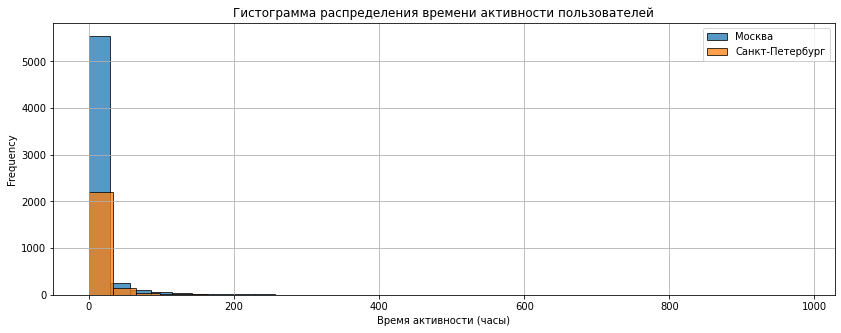

In [8]:
plt.figure(figsize=(14,5))
msk['hours'].plot(kind='hist', bins=30, alpha=0.75, edgecolor='black', label='Москва')
spb['hours'].plot(kind='hist', bins=30, alpha=0.75, edgecolor='black', label='Санкт-Петербург')
plt.xlabel('Время активности (часы)')
plt.title('Гистограмма распределения времени активности пользователей')
plt.legend()
plt.grid()
plt.show()

В интервале от 300 до 1000 часов есть выбросы - маленькие столбцы. Их значения очень малы, значит, к существенному искажению они не приводят, и их можно удалить. Оставим значения, которые будут меньше 99%-го процентиля этих рядов значений или равны ему.

In [9]:
msk = msk[msk['hours'] <= msk['hours'].quantile(0.99)]
spb = spb[spb['hours'] <= spb['hours'].quantile(0.99)]
print(f'Размеры выборок: Москва = {msk.shape[0]}, Санкт-Петербург = {spb.shape[0]}')

Размеры выборок: Москва = 6038, Санкт-Петербург = 2416


In [10]:
msk_mean = round(msk['hours'].mean(), 2)
msk_median = round(msk['hours'].median(), 2)
msk_std = round(msk['hours'].std(), 2)
msk_pct25 = round(msk['hours'].quantile(0.25), 2)
msk_pct75 = round(msk['hours'].quantile(0.75), 2)
print(f'В Москве средняя суммарная активность пользователей составляет {msk_mean} часов со стандартным отклонением {msk_std}, медианное значение - {msk_median} часа. Основная активность составляет от {msk_pct25} до {msk_pct75} часов.')


В Москве средняя суммарная активность пользователей составляет 8.29 часов со стандартным отклонением 20.22, медианное значение - 0.9 часа. Основная активность составляет от 0.06 до 5.79 часов.


In [11]:
spb_mean = round(spb['hours'].mean(), 2)
spb_median = round(spb['hours'].median(), 2)
spb_std = round(spb['hours'].std(), 2)
spb_pct25 = round(spb['hours'].quantile(0.25), 2)
spb_pct75 = round(spb['hours'].quantile(0.75), 2)
print(f'В Санкт-Петербурге средняя суммарная активность пользователей составляет {spb_mean} часов со стандартным отклонением {spb_std}, медианное значение - {spb_median} часа. Основная активность составляет от {spb_pct25} до {spb_pct75} часов.')


В Санкт-Петербурге средняя суммарная активность пользователей составляет 8.96 часов со стандартным отклонением 20.44, медианное значение - 0.98 часа. Основная активность составляет от 0.07 до 6.51 часов.


Средняя суммарная активность пользователей в Санкт-Петербурге выше - 8.96 часов по сравнению с 8.29 часами в Москве. Медианы обеих выборок существенно ниже их средних — данные имеют асимметричное распределение с правым "хвостом": большинство пользователей проявляют низкую активность, меньшая группа — высокую. Стандартные отклонения в обеих группах существенно превышают разницу между средними, что указывает на то, что основная масса пользователей в обоих городах имеет низкую активность по длительности чтения или прослушивания.

## 2. Проверка гипотезы в Python

Гипотеза звучит так: пользователи из Санкт-Петербурга проводят в среднем больше времени за чтением и прослушиванием книг в приложении, чем пользователи из Москвы. Попробуем статистически это доказать, используя одностороннюю проверку гипотезы с двумя выборками:

- Нулевая гипотеза H₀: Средняя активность пользователей в часах в двух группах (Москва и Санкт-Петербург) не различается.

- Альтернативная гипотеза H₁: Средняя активность пользователей в Санкт-Петербурге больше, и это различие статистически значимо.

In [12]:
results = st.ttest_ind(msk['hours'], spb['hours'], equal_var=False, alternative='less')
alpha = 0.05
p_value = results.pvalue
if p_value <= alpha:
    print(f"Полученное значение p_value={p_value} меньше критического уровня alpha={alpha}. Принимаем альтернативную гипотезу.")
    print("Средняя активность пользователей в Санкт-Петербурге больше, и это различие статистически значимо")
else:
    print(f"Полученное значение p_value={p_value} больше критического уровня alpha={alpha}. Опровергнуть нулевую гипотезу нельзя.")
    print("Средняя активность пользователей в часах в двух группах (Москва и Санкт-Петербург) не различается.")

Полученное значение p_value=0.08665084877150953 больше критического уровня alpha=0.05. Опровергнуть нулевую гипотезу нельзя.
Средняя активность пользователей в часах в двух группах (Москва и Санкт-Петербург) не различается.


## 3. Аналитическая записка

- Для проверки гипотезы о том, что пользователи из Санкт-Петербурга проводят в среднем больше времени за чтением и прослушиванием книг в приложении, чем пользователи из Москвы, был выбран двухвыборочный односторонний t-теста Уэлча, так как он корректно работает при неравных размерах выборок. Уровень значимости был выбран на уровне 0.05.  
- В результате теста полученное значение p-value составило ~0.09.  
- При оценке статистической значимости того, что средняя активность пользователей в Санкт-Петербурге получилась больше, чем в Москве, значение p-value получилось выше заданного уровня значимости 0.05, поэтому нулевая гипотеза о равенстве средней активности в двух группах не может быть отвергнута. Нет достаточных статистических оснований утверждать, что активность в Санкт-Петербурге выше, чем в Москве, наблюдаемая разница в средних значениях (~40 минут) может быть случайной.  
- Полученный результат может быть связан с тем, что поведение пользователей в Москве и Санкт-Петербурге практически совпадает: медиана ~0.9 часа, среднее ~8.5 часов. Наблюдаемая небольшая разница в средних может быть следствием случайного дисбаланса в составе выборки.

